# QUASR Finite-Beta Pipeline
Load 3 QA equilibria, visualize vacuum stage, run fixed-boundary VMEC at 2% beta, extract MHD quantities.

In [1]:
import os
import sys
import warnings

# Ensure tme/ modules are importable (run notebook from tme/ directory)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from load_quasr import load_quasr_equilibrium
from vmec_runner import prepare_vmec_input, run_vmec, run_vmec_to_target_beta
from visualize import (
    plot_vacuum_3d, plot_cross_sections,
    plot_vmec_profiles, plot_flux_surfaces, plot_finite_beta_3d,
)
from analysis import extract_vmec_results, run_boozer_analysis, save_results

# Configuration
QUASR_DIR = "QUASR_eq"
OUTPUT_BASE = "output"
EQUILIBRIA = {
    "0010273": {"symmetry_type": "QA"},
    "0019548": {"symmetry_type": "QA"},
    "0358936": {"symmetry_type": "QA"},
}

## Step 1: Load and Visualize Vacuum Equilibria


Loading 0010273 (QA)
  nfp=2, symmetry=QA
  Surface: SurfaceXYZTensorFourier1
  Coils: 8



Loading 0019548 (QA)
  nfp=2, symmetry=QA
  Surface: SurfaceXYZTensorFourier6
  Coils: 12


/tmp/ipykernel_12247/1048625601.py:28: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown




Loading 0358936 (QA)
  nfp=2, symmetry=QA
  Surface: SurfaceXYZTensorFourier11
  Coils: 8


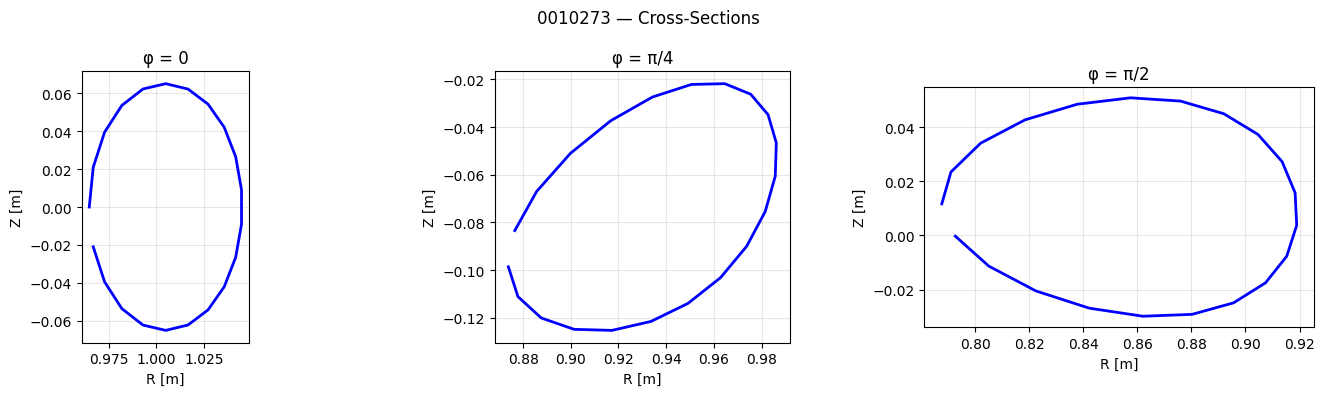

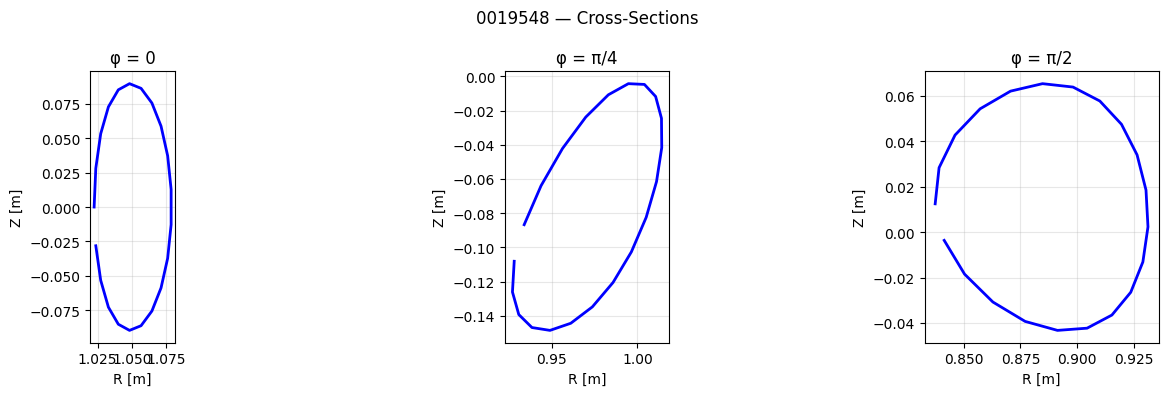

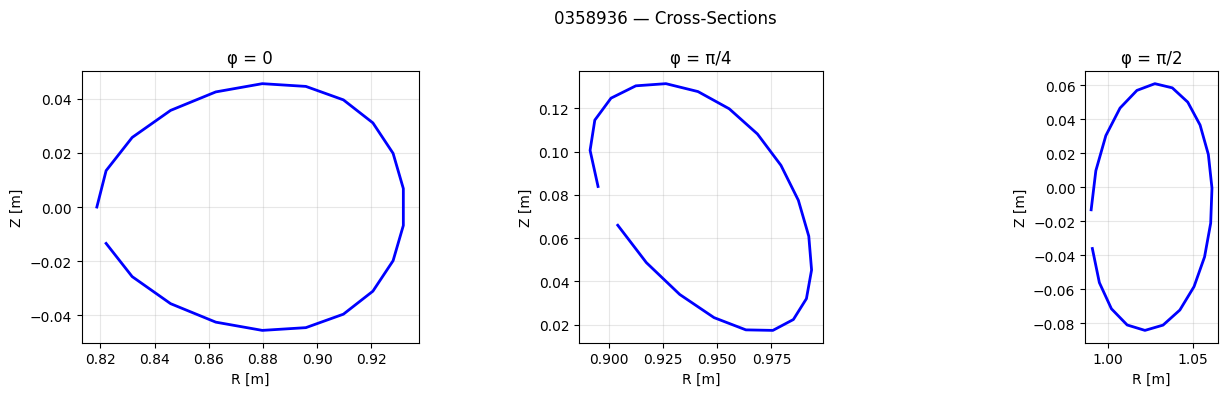

In [2]:
equilibria = {}

for model_id, config in EQUILIBRIA.items():
    print(f"\n{'='*60}")
    print(f"Loading {model_id} ({config['symmetry_type']})")
    print(f"{'='*60}")

    serial_file = os.path.join(QUASR_DIR, f"serial{model_id}.json")
    eq = load_quasr_equilibrium(
        serial_file,
        symmetry_type=config["symmetry_type"],
    )
    equilibria[model_id] = eq

    meta = eq["metadata"]
    print(f"  nfp={meta['nfp']}, symmetry={meta['symmetry_type']}")
    print(f"  Surface: {eq['surface']}")
    print(f"  Coils: {len(eq['coils'])}")

    # 3D vacuum visualization
    fig_3d = plot_vacuum_3d(eq["surface"], eq["coils"], eq["bs"])
    fig_3d.update_layout(title=f"{model_id} — Vacuum 3D")
    fig_3d.show()

    # Cross-sections
    fig_cs = plot_cross_sections(eq["surface"], meta["nfp"])
    fig_cs.suptitle(f"{model_id} — Cross-Sections")
    fig_cs.show()

## Step 2: Run Fixed-Boundary VMEC at 2% Beta

In [3]:
wout_paths = {}

for model_id, eq in equilibria.items():
    print(f"\n{'='*60}")
    print(f"Running VMEC for {model_id}")
    print(f"{'='*60}")

    output_dir = os.path.join(OUTPUT_BASE, model_id)
    input_template = os.path.join(QUASR_DIR, f"input.{model_id}")

    try:
        wout_path = run_vmec_to_target_beta(
            eq["surface"],
            eq["metadata"],
            output_dir,
            input_template=input_template,
        )
        wout_paths[model_id] = wout_path
        print(f"  VMEC converged! wout: {wout_path}")

    except Exception as e:
        warnings.warn(f"VMEC failed for {model_id}: {e}")
        print(f"  FAILED: {e}")

print(f"\nSuccessful runs: {len(wout_paths)}/{len(equilibria)}")


Running VMEC for 0010273
 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
  VMEC OUTPUT FILES ALREADY EXIST: OVERWRITING THEM ...
  SEQ =    1 TIME SLICE  0.0000E+00
  PROCESSING INPUT.0010273
  THIS IS PARVMEC (PARALLEL VMEC), VERSION 9.0
  Lambda: Full Radial Mesh. L-Force: hybrid full/half.

  COMPUTER: x86_64-conda-linux-gnu   OS:    RELEASE: x86_64  DATE = Mar 19,2026  TIME = 10:46:33



  NS =   16 NO. FOURIER MODES =  200 FTOLV =  1.000E-08 NITER =   2000
  PROCESSOR COUNT - RADIAL:    1
 INITIAL JACOBIAN CHANGED SIGN!
 TRYING TO IMPROVE INITIAL MAGNETIC AXIS GUESS
  ---- Improved AXIS Guess ----
      RAXIS_CC =   0.92480036279280242        4.3505434155684169E-002  -7.8909770938298384E-003   9.2492268604363066E-003   5.9576892977092509E-003  -5.5693493689592333E-003   3.6414157198380276E-003  -1.8297052426652018E-003  -1.1369298347379264E-003   3.1909026829338529E-003  -1.7218577407364076E-003
      ZAXIS_CS =   -0.0000000000000000        6.2866501480629805E-002   4.0897866320718989E-003   2.0662833747853528E-003  -1.0688858725586262E-003  -2.4510682969251178E-004   5.7140826414593210E-005  -2.2902248318382504E-004   1.3404981074963912E-003   1.1263429839536445E-005  -1.3373099436937623E-003
  -----------------------------

  ITER    FSQR      FSQZ      FSQL    RAX(v=0)    DELT       WMHD

    1  1.60E+02  7.41E+01  5.62E-01  9.722E-01  1.00E+00  1.8541E+01
  200  

 INITIAL JACOBIAN CHANGED SIGN!
 TRYING TO IMPROVE INITIAL MAGNETIC AXIS GUESS
  ---- Improved AXIS Guess ----
      RAXIS_CC =   0.92480036279280242        4.3505434155684169E-002  -7.8909770938298384E-003   9.2492268604363066E-003   5.9576892977092509E-003  -5.5693493689592333E-003   3.6414157198380276E-003  -1.8297052426652018E-003  -1.1369298347379264E-003   3.1909026829338529E-003  -1.7218577407364076E-003
      ZAXIS_CS =   -0.0000000000000000        6.2866501480629805E-002   4.0897866320718989E-003   2.0662833747853528E-003  -1.0688858725586262E-003  -2.4510682969251178E-004   5.7140826414593210E-005  -2.2902248318382504E-004   1.3404981074963912E-003   1.1263429839536445E-005  -1.3373099436937623E-003
  -----------------------------

  ITER    FSQR      FSQZ      FSQL    RAX(v=0)    DELT       WMHD

    1  1.61E+02  7.45E+01  5.62E-01  9.722E-01  1.00E+00  1.8243E+01
  200  3.31E-04  1.06E-04  1.90E-05  1.023E+00  2.54E-01  1.5887E+01
  400  5.90E-06  2.31E-06  1.51E-06  1.072E


  NS =   16 NO. FOURIER MODES =  200 FTOLV =  1.000E-08 NITER =   2000
  PROCESSOR COUNT - RADIAL:    1
 INITIAL JACOBIAN CHANGED SIGN!
 TRYING TO IMPROVE INITIAL MAGNETIC AXIS GUESS
  ---- Improved AXIS Guess ----
      RAXIS_CC =   0.99812589509274718        5.8819058708254206E-002  -1.7152738316455842E-003  -4.2824857556101039E-003  -2.8916302141192602E-003   2.4333194085325444E-003   1.5201994447280169E-003  -3.2076882995156460E-003   4.0525965425859496E-003  -5.2923935805230507E-004  -3.3077916719221221E-003
      ZAXIS_CS =   -0.0000000000000000        5.4568976639927290E-002  -5.0965565923321724E-003  -1.7816448739634318E-003   2.0968197245971633E-003   2.4802961343477234E-003  -1.8848334078767329E-003   1.6254454909088814E-003   1.9229809791244739E-003  -1.2245644619861991E-003   2.8253220220464245E-003
  -----------------------------

  ITER    FSQR      FSQZ      FSQL    RAX(v=0)    DELT       WMHD

    1  6.65E-01  6.92E-01  1.49E-01  1.049E+00  1.00E+00  1.7527E+01
  200  

 INITIAL JACOBIAN CHANGED SIGN!
 TRYING TO IMPROVE INITIAL MAGNETIC AXIS GUESS
  ---- Improved AXIS Guess ----
      RAXIS_CC =   0.99812589509274718        5.8819058708254206E-002  -1.7152738316455842E-003  -4.2824857556101039E-003  -2.8916302141192602E-003   2.4333194085325444E-003   1.5201994447280169E-003  -3.2076882995156460E-003   4.0525965425859496E-003  -5.2923935805230507E-004  -3.3077916719221221E-003
      ZAXIS_CS =   -0.0000000000000000        5.4568976639927290E-002  -5.0965565923321724E-003  -1.7816448739634318E-003   2.0968197245971633E-003   2.4802961343477234E-003  -1.8848334078767329E-003   1.6254454909088814E-003   1.9229809791244739E-003  -1.2245644619861991E-003   2.8253220220464245E-003
  -----------------------------

  ITER    FSQR      FSQZ      FSQL    RAX(v=0)    DELT       WMHD

    1  6.70E-01  6.97E-01  1.49E-01  1.049E+00  1.00E+00  1.7211E+01
  200  2.23E-06  2.27E-06  8.74E-07  1.071E+00  5.73E-01  1.6162E+01
  400  1.32E-07  1.81E-08  2.91E-08  1.076E

 INITIAL JACOBIAN CHANGED SIGN!
 TRYING TO IMPROVE INITIAL MAGNETIC AXIS GUESS
  ---- Improved AXIS Guess ----
      RAXIS_CC =    1.0038237534535273       -4.3172214886996400E-002   1.3195886931623739E-003   1.6149999731146069E-003  -5.8360789358560903E-004  -2.3842325937955943E-003  -6.2668806907183678E-003   1.6730006921672800E-004   1.3668215922281110E-003   1.0573646203631893E-003   3.0026691395011779E-003
      ZAXIS_CS =   -0.0000000000000000       -6.0329417897136396E-002   6.7843503548082511E-005   1.3531797518779474E-003   2.2473715060626097E-004   1.0100620841619831E-003   1.6971727205513076E-004  -3.5046380900720067E-003   3.7489048225257745E-004  -1.8994746374820081E-003   1.2617965809731091E-004
  -----------------------------

  ITER    FSQR      FSQZ      FSQL    RAX(v=0)    DELT       WMHD

    1  1.70E+00  1.34E+00  1.71E-01  9.599E-01  1.00E+00  1.7984E+01
  200  1.71E-06  8.57E-07  3.77E-07  9.381E-01  5.31E-01  1.6370E+01
  400  1.02E-07  3.45E-08  3.42E-08  9.416E


  NS =   16 NO. FOURIER MODES =  200 FTOLV =  1.000E-08 NITER =   2000
  PROCESSOR COUNT - RADIAL:    1
 INITIAL JACOBIAN CHANGED SIGN!
 TRYING TO IMPROVE INITIAL MAGNETIC AXIS GUESS
  ---- Improved AXIS Guess ----
      RAXIS_CC =    1.0038237534535273       -4.3172214886996400E-002   1.3195886931623739E-003   1.6149999731146069E-003  -5.8360789358560903E-004  -2.3842325937955943E-003  -6.2668806907183678E-003   1.6730006921672800E-004   1.3668215922281110E-003   1.0573646203631893E-003   3.0026691395011779E-003
      ZAXIS_CS =   -0.0000000000000000       -6.0329417897136396E-002   6.7843503548082511E-005   1.3531797518779474E-003   2.2473715060626097E-004   1.0100620841619831E-003   1.6971727205513076E-004  -3.5046380900720067E-003   3.7489048225257745E-004  -1.8994746374820081E-003   1.2617965809731091E-004
  -----------------------------

  ITER    FSQR      FSQZ      FSQL    RAX(v=0)    DELT       WMHD

    1  1.71E+00  1.35E+00  1.71E-01  9.599E-01  1.00E+00  1.7669E+01
  200  

## Step 3: Extract MHD Quantities and Boozer Analysis

In [4]:
all_results = {}

for model_id, wout_path in wout_paths.items():
    print(f"\n{'='*60}")
    print(f"Analyzing {model_id}")
    print(f"{'='*60}")

    eq = equilibria[model_id]
    results = extract_vmec_results(wout_path)
    print(f"  beta = {results['betatot']:.4e}")
    print(f"  ier_flag = {results['ier_flag']}")
    print(f"  fsql = {results['fsql']:.2e}")
    print(f"  iota(0) = {results['iotaf'][0]:.4f}, iota(1) = {results['iotaf'][-1]:.4f}")

    # Boozer analysis
    try:
        boozer = run_boozer_analysis(wout_path)
        results.update(boozer)
        print(f"  Boozer: {len(boozer['bmnc_b'])} dominant modes")
        if boozer["epsilon_eff"]:
            print(f"  epsilon_eff(LCFS) = {boozer['epsilon_eff'][-1]:.4e}")
    except Exception as e:
        warnings.warn(f"Boozer failed for {model_id}: {e}")
        print(f"  Boozer FAILED: {e}")

    # Save results
    output_dir = os.path.join(OUTPUT_BASE, model_id)
    save_results(results, eq["metadata"], output_dir, wout_path=wout_path)
    print(f"  Results saved to {output_dir}/results.json")

    all_results[model_id] = results


Analyzing 0010273
  beta = 2.1263e-02
  ier_flag = 0
  fsql = 1.62e-11
  iota(0) = -0.6237, iota(1) = -0.2788


  Boozer: 10 dominant modes
  Results saved to output/0010273/results.json

Analyzing 0019548
  beta = 2.0350e-02
  ier_flag = 0
  fsql = 4.05e-12
  iota(0) = -0.9014, iota(1) = -0.3480


  Boozer: 10 dominant modes
  Results saved to output/0019548/results.json

Analyzing 0358936
  beta = 2.0504e-02
  ier_flag = 0
  fsql = 2.44e-11
  iota(0) = -0.9255, iota(1) = -0.3927


  Boozer: 10 dominant modes
  Results saved to output/0358936/results.json


## Step 4: Finite-Beta Visualization


Finite-beta plots for 0010273


/tmp/ipykernel_12247/647428046.py:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



/tmp/ipykernel_12247/647428046.py:14: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown




Finite-beta plots for 0019548



Finite-beta plots for 0358936


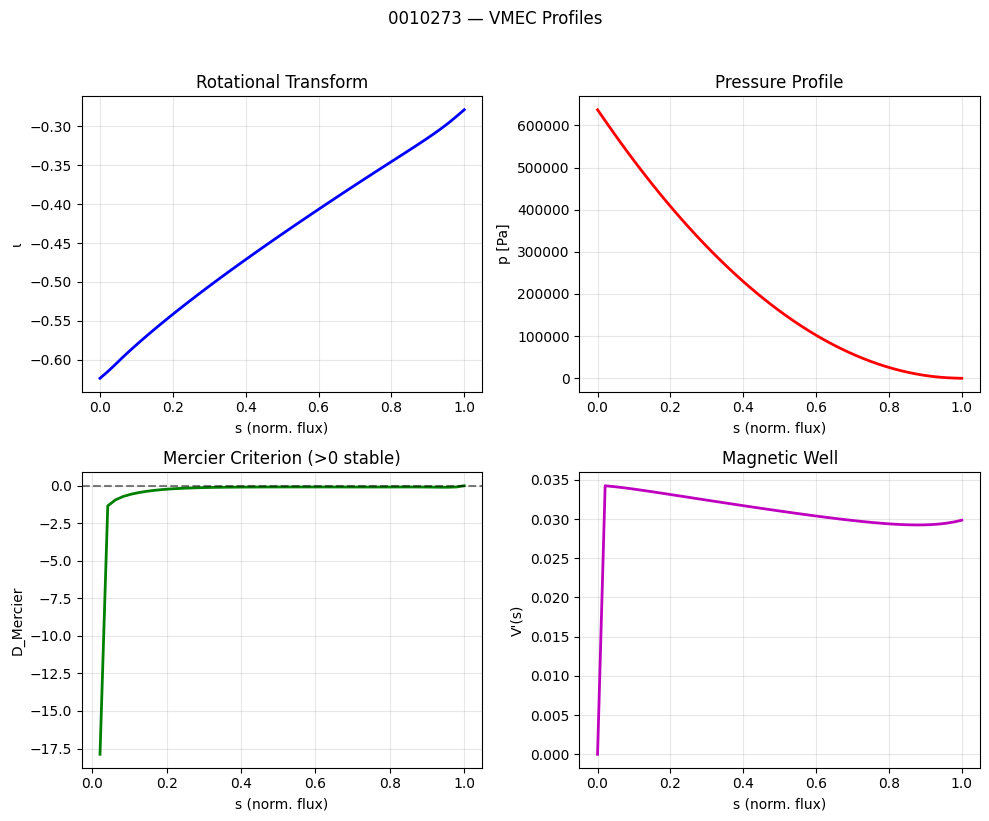

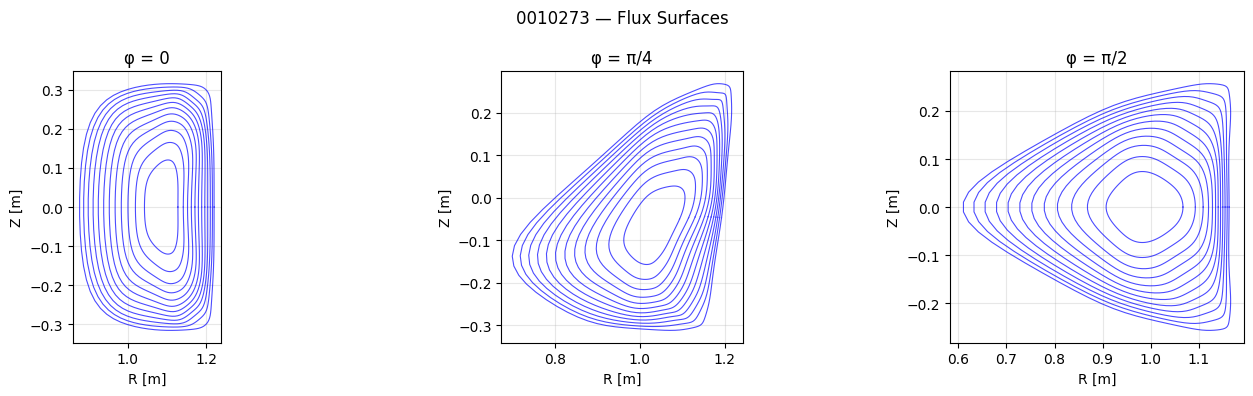

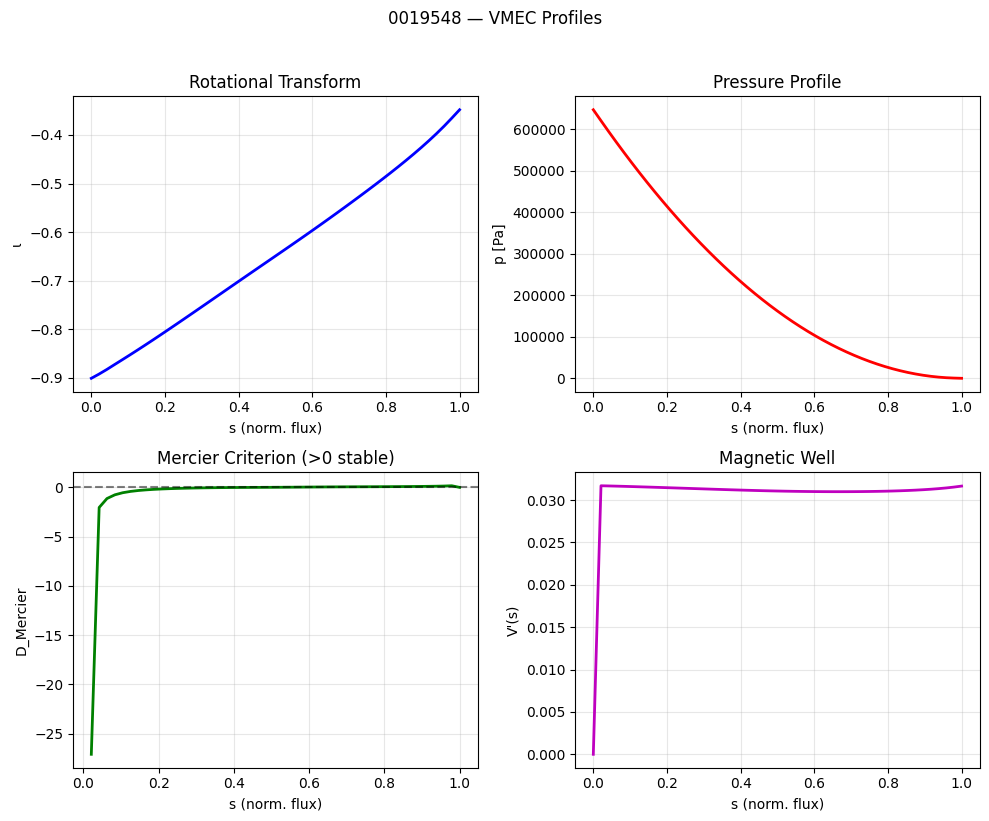

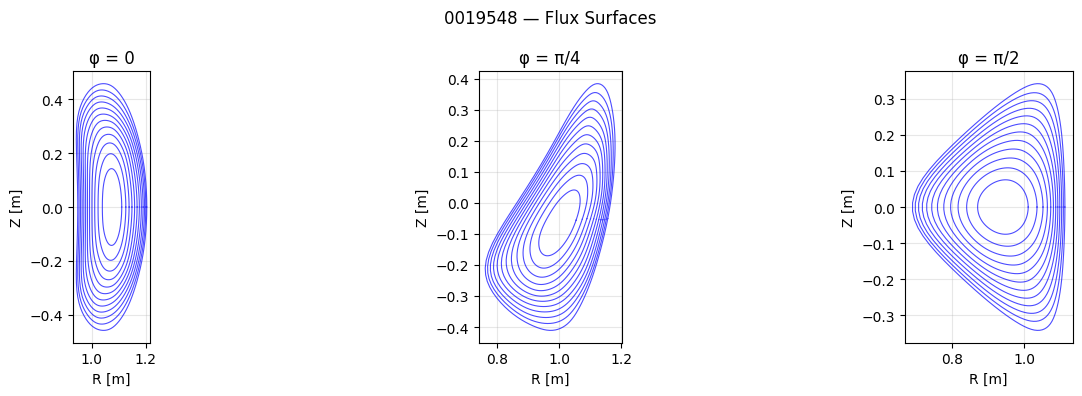

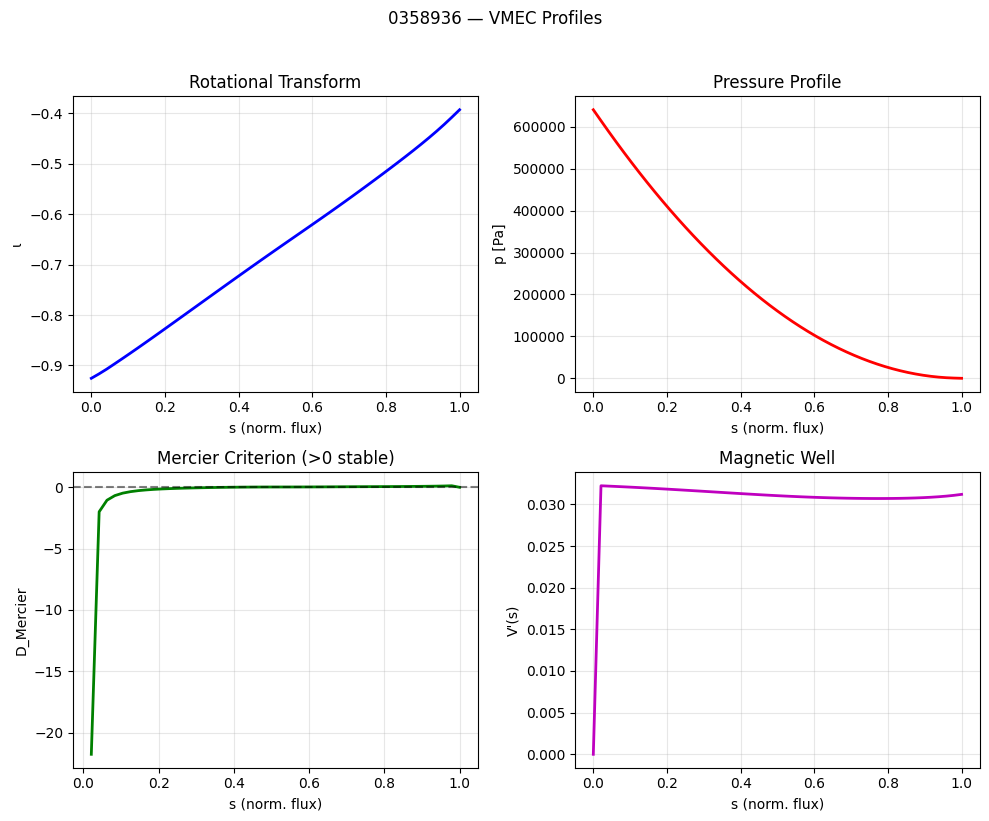

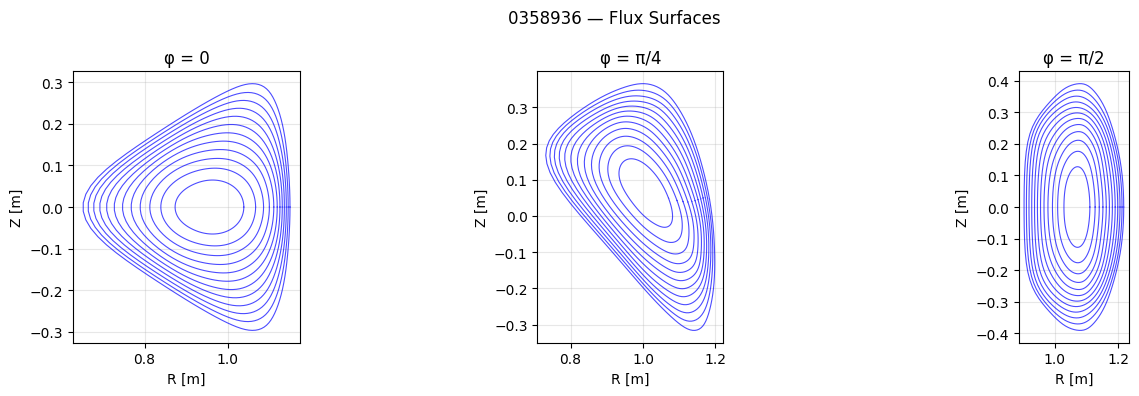

In [5]:
for model_id, wout_path in wout_paths.items():
    print(f"\n{'='*60}")
    print(f"Finite-beta plots for {model_id}")
    print(f"{'='*60}")

    # Profile plots (iota, pressure, Mercier, magnetic well)
    fig_prof = plot_vmec_profiles(wout_path)
    fig_prof.suptitle(f"{model_id} — VMEC Profiles", y=1.02)
    fig_prof.show()

    # Flux surface cross-sections
    fig_flux = plot_flux_surfaces(wout_path)
    fig_flux.suptitle(f"{model_id} — Flux Surfaces")
    fig_flux.show()

    # 3D finite-beta surface colored by |B|
    fig_3d = plot_finite_beta_3d(wout_path)
    fig_3d.update_layout(title=f"{model_id} — Finite-Beta |B|")
    fig_3d.show()

## Summary

In [6]:
import pandas as pd

rows = []
for model_id, results in all_results.items():
    row = {
        "model_id": model_id,
        "symmetry": equilibria[model_id]["metadata"]["symmetry_type"],
        "nfp": results.get("nfp", ""),
        "beta_target": 0.02,
        "beta_achieved": f"{results['betatot']:.4e}",
        "iota_axis": f"{results['iotaf'][0]:.4f}",
        "iota_edge": f"{results['iotaf'][-1]:.4f}",
        "Mercier_min": f"{min(results['DMerc']):.4e}",
        "converged": results.get("ier_flag", -1) == 0,
        "fsql": f"{results['fsql']:.2e}",
    }
    if "epsilon_eff" in results and results["epsilon_eff"]:
        row["eps_eff_LCFS"] = f"{results['epsilon_eff'][-1]:.4e}"
    rows.append(row)

df = pd.DataFrame(rows)
print("Pipeline complete.\n")
df

Pipeline complete.



,model_id,symmetry,nfp,beta_target,beta_achieved,iota_axis,iota_edge,Mercier_min,converged,fsql
0,0010273,QA,2,0.02,2.1263e-02,-0.6237,-0.2788,-1.7884e+01,True,1.62e-11
1,0019548,QA,2,0.02,2.0350e-02,-0.9014,-0.3480,-2.7084e+01,True,4.05e-12
2,0358936,QA,2,0.02,2.0504e-02,-0.9255,-0.3927,-2.1777e+01,True,2.44e-11
